# Import Libraries

In [1]:
# Import core data science and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Set plot styles for a professional look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load and Preprocess the Dataset

In [ ]:
# Load the uploaded Udemy course dataset
df = pd.read_csv("udemy_course_data.csv")
df


,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,profit,published_date,published_time,year,month,day
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5 hours,2017-01-18T20:58:58Z,Business Finance,429400,2017-01-18,20:58:58Z,2017,1,18
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39 hours,2017-03-09T16:34:20Z,Business Finance,209400,2017-03-09,16:34:20Z,2017,3,9
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5 hours,2016-12-19T19:26:30Z,Business Finance,97830,2016-12-19,19:26:30Z,2016,12,19
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3 hours,2017-05-30T20:07:24Z,Business Finance,232845,2017-05-30,20:07:24Z,2017,5,30
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2 hours,2016-12-13T14:57:18Z,Business Finance,255200,2016-12-13,14:57:18Z,2016,12,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3678,775618,Learn jQuery from Scratch - Master of JavaScri...,https://www.udemy.com/easy-jquery-for-beginner...,True,100,1040,14,21,All Levels,2 hours,2016-06-14T17:36:46Z,Web Development,104000,2016-06-14,17:36:46Z,2016,6,14
3679,1088178,How To Design A WordPress Website With No Codi...,https://www.udemy.com/how-to-make-a-wordpress-...,True,25,306,3,42,Beginner Level,3.5 hours,2017-03-10T22:24:30Z,Web Development,7650,2017-03-10,22:24:30Z,2017,3,10
3680,635248,Learn and Build using Polymer,https://www.udemy.com/learn-and-build-using-po...,True,40,513,169,48,All Levels,3.5 hours,2015-12-30T16:41:42Z,Web Development,20520,2015-12-30,16:41:42Z,2015,12,30
3681,905096,CSS Animations: Create Amazing Effects on Your...,https://www.udemy.com/css-animations-create-am...,True,50,300,31,38,All Levels,3 hours,2016-08-11T19:06:15Z,Web Development,15000,2016-08-11,19:06:15Z,2016,8,11


In [5]:

# Display basic structure of the data to understand features
print("Dataset Shape:", df.shape)
print("\nMissing Values per Column:")
print(df.isnull().sum())



Dataset Shape: (3683, 18)

Missing Values per Column:
course_id              0
course_title           0
url                    0
is_paid                0
price                  0
num_subscribers        0
num_reviews            0
num_lectures           0
level                  0
content_duration       0
published_timestamp    0
subject                0
profit                 0
published_date         0
published_time         1
year                   0
month                  0
day                    0
dtype: int64


In [6]:
# Handle missing values in categorical columns if any
df['course_title'] = df['course_title'].fillna('')
df['subject'] = df['subject'].fillna('')
df['level'] = df['level'].fillna('All Levels')
df['published_time'] = df['published_time'].fillna('Unknown')
print(df.isnull().sum())

course_id              0
course_title           0
url                    0
is_paid                0
price                  0
num_subscribers        0
num_reviews            0
num_lectures           0
level                  0
content_duration       0
published_timestamp    0
subject                0
profit                 0
published_date         0
published_time         0
year                   0
month                  0
day                    0
dtype: int64


In [7]:
# Create a combined feature string for text analysis (Pattern Alignment)
df['content_features'] = df['course_title'] + " " + df['subject'] + " " + df['level']

# Preview the engineered features
df[['course_title', 'content_features']].head()

,course_title,content_features
0,Ultimate Investment Banking Course,Ultimate Investment Banking Course Business Fi...
1,Complete GST Course & Certification - Grow You...,Complete GST Course & Certification - Grow You...
2,Financial Modeling for Business Analysts and C...,Financial Modeling for Business Analysts and C...
3,Beginner to Pro - Financial Analysis in Excel ...,Beginner to Pro - Financial Analysis in Excel ...
4,How To Maximize Your Profits Trading Options,How To Maximize Your Profits Trading Options B...


# Vectorization (TF-IDF) & Cosine Similarity Math

In [8]:
# Initialize TF-IDF Vectorizer to penalize generic terms and reward descriptive keywords
# This fulfills the "Beyond Binary Overlap" requirement specified in the PDF
tfidf = TfidfVectorizer(stop_words='english')

# Transform text features into a numerical matrix
tfidf_matrix = tfidf.fit_transform(df['content_features'])
print("TF-IDF Matrix Shape (Items x Vocabulary Size):", tfidf_matrix.shape)

# Compute the Cosine Similarity Matrix based on continuous vectors
cosine_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine Similarity Matrix Shape:", cosine_sim_matrix.shape)

TF-IDF Matrix Shape (Items x Vocabulary Size): (3683, 3580)
Cosine Similarity Matrix Shape: (3683, 3683)


# Define Recommendation Logic Function

In [9]:
def get_content_based_recommendations(course_title, top_n=5):
    """
    Returns top N recommended courses based on content similarity math.
    """
    # Find the index of the matching course title
    try:
        idx = df[df['course_title'] == course_title].index[0]
    except IndexError:
        print(f"Error: Course title '{course_title}' not found in the dataset.")
        return None

    # Extract similarity scores for this specific course against all others
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))

    # Sort courses based on higher similarity scores in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get indices of top items (excluding the selected item itself)
    top_sim_scores = sim_scores[1:top_n+1]
    course_indices = [i[0] for i in top_sim_scores]

    # Return structured recommendation dataframe
    output_df = df.iloc[course_indices][['course_title', 'subject', 'level', 'price', 'num_subscribers']]
    return output_df

# Test the Recommendation Engine

In [10]:
# Select a sample course title from the dataset to test the logic
sample_course = df['course_title'].iloc[0] 
print(f"Generating recommendations for: '{sample_course}'\n")

# Call the logic function
recommendations = get_content_based_recommendations(sample_course, top_n=5)

# Display recommendations
if recommendations is not None:
    display(recommendations)

Generating recommendations for: 'Ultimate Investment Banking Course'



,course_title,subject,level,price,num_subscribers
39,The Complete Investment Banking Course 2017,Business Finance,All Levels,195,8575
242,Advanced Accounting for Investment Banking,Business Finance,Intermediate Level,50,1260
419,The Investment Banking Recruitment Series,Business Finance,All Levels,40,17
420,Business Banking 101,Business Finance,All Levels,25,132
139,"Intro to Investment Banking, M&A, IPO, Modelin...",Business Finance,All Levels,60,1922


# Graphical Representation

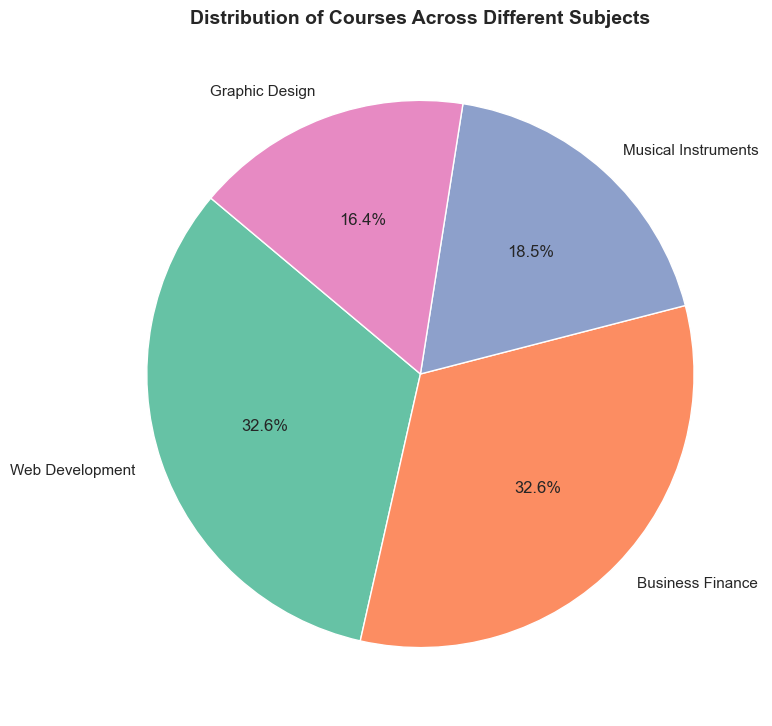

In [11]:
# Plot 1: Pie chart showing the distribution of course subjects in the database
plt.figure(figsize=(8, 8))
subject_counts = df['subject'].value_counts()

plt.pie(subject_counts, labels=subject_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette("Set2"), startangle=140, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})

plt.title("Distribution of Courses Across Different Subjects", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('subject_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.show()

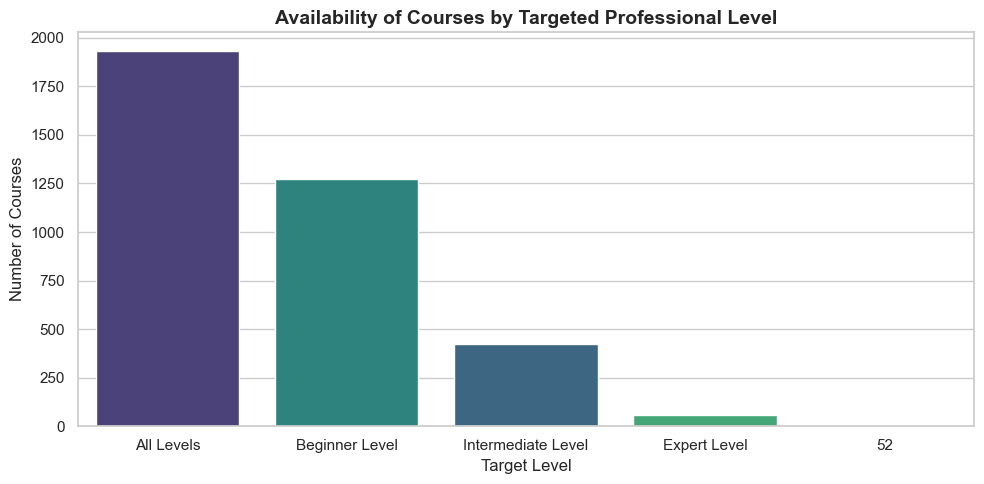

In [ ]:
# Plot 2: Count plot analyzing which learning levels are targeted the most
plt.figure(figsize=(10, 5))

# Sahi tarika: hue='level' aur legend=False lagaya hai warning khatam karne ke liye
sns.countplot(
    data=df, 
    x='level', 
    order=df['level'].value_counts().index, 
    palette="viridis", 
    hue='level', 
    legend=False
)

plt.title("Availability of Courses by Targeted Professional Level", fontsize=14, fontweight='bold')
plt.xlabel("Target Level", fontsize=12)
plt.ylabel("Number of Courses", fontsize=12)
plt.tight_layout()
plt.savefig('experience_levels.png', dpi=300, bbox_inches='tight')
plt.show()

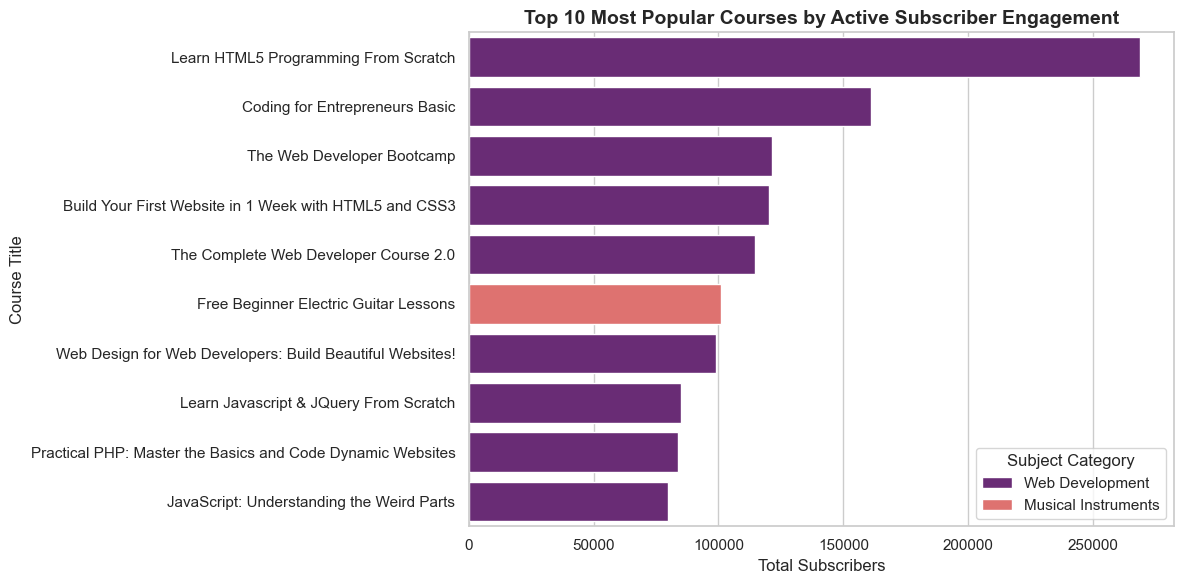

In [14]:
# Plot 3: Horizontal bar chart showing top items by engagement/subscriber count
plt.figure(figsize=(12, 6))
top_ten_popular = df.nlargest(10, 'num_subscribers')

sns.barplot(data=top_ten_popular, x='num_subscribers', y='course_title', 
            hue='subject', palette="magma", dodge=False)

plt.title("Top 10 Most Popular Courses by Active Subscriber Engagement", fontsize=14, fontweight='bold')
plt.xlabel("Total Subscribers", fontsize=12)
plt.ylabel("Course Title", fontsize=12)
plt.legend(title="Subject Category")
plt.tight_layout()
plt.savefig('top_popular_courses.png', dpi=300, bbox_inches='tight')
plt.show()

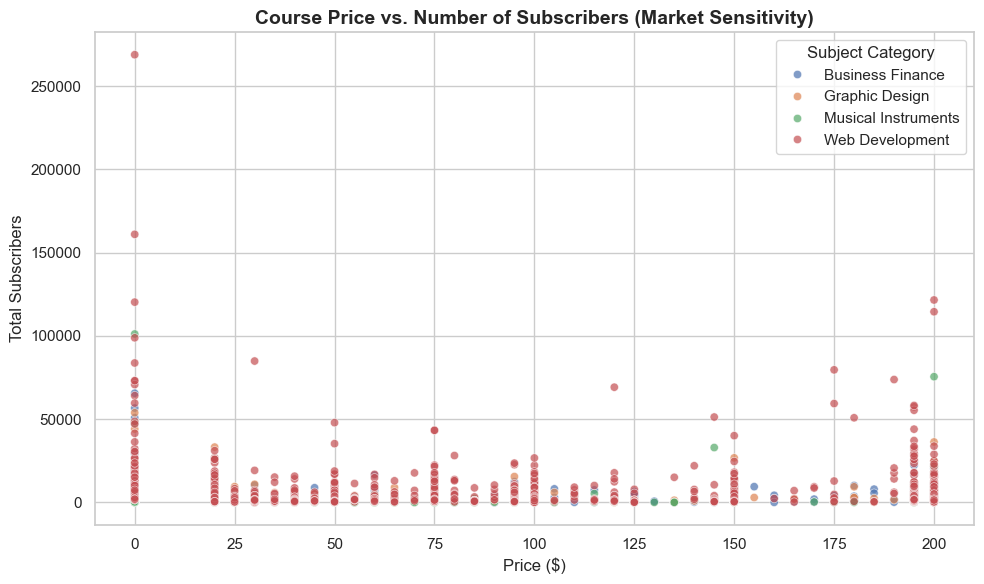

In [15]:
# Plot 4: Scatter plot exploring the relationship between Course Price and Subscriber Count
plt.figure(figsize=(10, 6))

# Clean the price column (convert 'Free' or strings to 0, and ensure it's numeric)
df_clean_price = df.copy()
df_clean_price['price_numeric'] = pd.to_numeric(df_clean_price['price'].astype(str).str.replace('Free', '0').str.replace('$', '', regex=False), errors='coerce').fillna(0)

sns.scatterplot(data=df_clean_price, x='price_numeric', y='num_subscribers', hue='subject', alpha=0.7, palette="deep")

plt.title("Course Price vs. Number of Subscribers (Market Sensitivity)", fontsize=14, fontweight='bold')
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Total Subscribers", fontsize=12)
plt.legend(title="Subject Category")
plt.tight_layout()
plt.savefig('price_vs_subscribers.png', dpi=300, bbox_inches='tight')
plt.show()

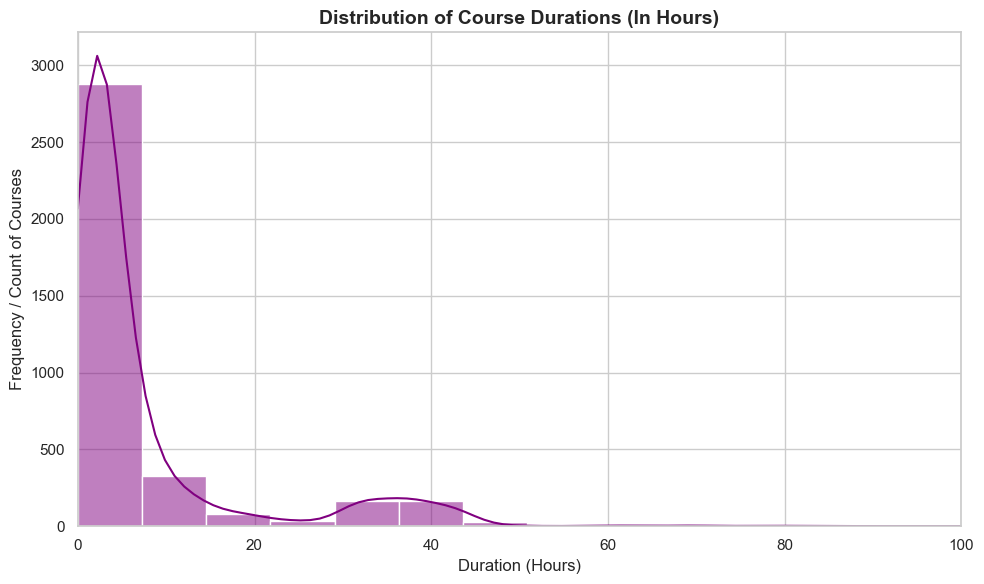

In [ ]:
# Plot 5: Distribution of course durations to understand the density of content lengths
plt.figure(figsize=(10, 6))

# Extract numeric value from 'content_duration' string (e.g., '1.5 hours' -> 1.5)
df_duration = df.copy()
df_duration['duration_hours'] = df_duration['content_duration'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float).fillna(0)

# Plotting the distribution using a histogram with a Kernel Density Estimate (KDE) line
sns.histplot(data=df_duration, x='duration_hours', bins=30, kde=True, color="purple", log_scale=(False, False))

# Restricting x-axis to 100 hours to avoid extreme outliers messing up the look
plt.xlim(0, 100)

plt.title("Distribution of Course Durations (In Hours)", fontsize=14, fontweight='bold')
plt.xlabel("Duration (Hours)", fontsize=12)
plt.ylabel("Frequency / Count of Courses", fontsize=12)
plt.tight_layout()
plt.savefig('course_duration_distribution.png', dpi=300, bbox_inches='tight')
plt.show()